In [9]:
import pandas as pd

In [11]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (6)\global_air_quality_dataset.csv")
print("Dataset shape:", df.shape)
print("Columns:", df.columns)



Dataset shape: (3660, 13)
Columns: Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')


In [15]:
def assign_aqi_category(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

df['AQI_Category'] = df['AQI'].apply(assign_aqi_category)
print("AQI Category distribution:")
print(df['AQI_Category'].value_counts())


AQI Category distribution:
AQI_Category
Very Unhealthy                    1360
Moderate                           673
Unhealthy                          666
Unhealthy for Sensitive Groups     664
Good                               297
Name: count, dtype: int64


In [21]:
print("""In Assignment 4, I continue the AQI project from Assignment 3. 
The cleaned dataset and AQI categories created earlier are reused. 
Visualizations such as AQI distribution and pollutant correlations are referenced 
to connect the RL task with the previous analysis. 
The same GitHub repository is extended with a new notebook and RL outputs folder.""")


In Assignment 4, I continue the AQI project from Assignment 3. 
The cleaned dataset and AQI categories created earlier are reused. 
Visualizations such as AQI distribution and pollutant correlations are referenced 
to connect the RL task with the previous analysis. 
The same GitHub repository is extended with a new notebook and RL outputs folder.


In [23]:
# Define RL components

# States (based on AQI ranges)
states = ["Low", "Medium", "High"]

# Actions
actions = ["No Restriction", "Partial Restriction", "High-Pollution Alert"]

# Reward system
reward_table = {
    "Low":    [10, -2, -5],   # Best: No Restriction
    "Medium": [-6, 10, 2],    # Best: Partial Restriction
    "High":   [-10, -3, 10]   # Best: High-Pollution Alert
}

print("States:", states)
print("Actions:", actions)
print("Reward Table:", reward_table)


States: ['Low', 'Medium', 'High']
Actions: ['No Restriction', 'Partial Restriction', 'High-Pollution Alert']
Reward Table: {'Low': [10, -2, -5], 'Medium': [-6, 10, 2], 'High': [-10, -3, 10]}


In [35]:
print("""-Low AQI (0–100): Represents Good and Moderate conditions.
-Medium AQI (101–200): Represents Unhealthy for Sensitive Groups and Unhealthy conditions.
-High AQI (201+): Represents Very Unhealthy and Hazardous conditions.

This simplified 3‑state design was chosen for clarity and ease of implementation.""")

-Low AQI (0–100): Represents Good and Moderate conditions.
-Medium AQI (101–200): Represents Unhealthy for Sensitive Groups and Unhealthy conditions.
-High AQI (201+): Represents Very Unhealthy and Hazardous conditions.

This simplified 3‑state design was chosen for clarity and ease of implementation.


In [25]:
# Step C: Map AQI values into RL states

def map_aqi_state(aqi):
    if aqi <= 100:
        return "Low"
    elif aqi <= 200:
        return "Medium"
    else:
        return "High"

df['RL_State'] = df['AQI'].apply(map_aqi_state)

# Check mapping
print(df[['AQI','AQI_Category','RL_State']].head(10))
print("RL State distribution:")
print(df['RL_State'].value_counts())


   AQI                    AQI_Category RL_State
0   38                            Good      Low
1  280                  Very Unhealthy     High
2  117  Unhealthy for Sensitive Groups   Medium
3  197                       Unhealthy   Medium
4  187                       Unhealthy   Medium
5  170                       Unhealthy   Medium
6  177                       Unhealthy   Medium
7  164                       Unhealthy   Medium
8  123  Unhealthy for Sensitive Groups   Medium
9  241                  Very Unhealthy     High
RL State distribution:
RL_State
High      1360
Medium    1330
Low        970
Name: count, dtype: int64


In [31]:
print("""In RL, the agent needs a set of actions it can take. For this AQI traffic‑control problem, we use 3 actions:

-No Restriction → when AQI is Low
-Partial Restriction → when AQI is Medium
-High‑Pollution Alert → when AQI is High""")

In RL, the agent needs a set of actions it can take. For this AQI traffic‑control problem, we use 3 actions:

-No Restriction → when AQI is Low
-Partial Restriction → when AQI is Medium
-High‑Pollution Alert → when AQI is High


In [37]:
# Step D: Define action space
actions = {0: "No Restriction", 
           1: "Partial Restriction", 
           2: "High-Pollution Alert"}

print("Available Actions:")
for k,v in actions.items():
    print(f"{k}: {v}")


Available Actions:
0: No Restriction
1: Partial Restriction
2: High-Pollution Alert


In [39]:
# Step E: Reward System

reward_table = {
    "Low":    [10, -2, -5],   # Best: No Restriction
    "Medium": [-6, 10, 2],    # Best: Partial Restriction
    "High":   [-10, -3, 10]   # Best: High-Pollution Alert
}

print("Reward Table:")
print("State | No Restriction | Partial Restriction | High-Pollution Alert")
for state, rewards in reward_table.items():
    print(f"{state:6} | {rewards[0]:>14} | {rewards[1]:>18} | {rewards[2]:>21}")


Reward Table:
State | No Restriction | Partial Restriction | High-Pollution Alert
Low    |             10 |                 -2 |                    -5
Medium |             -6 |                 10 |                     2
High   |            -10 |                 -3 |                    10


In [43]:
print("""A reward system was designed to balance public‑health protection and traffic disruption.

-Low AQI (0–100): The best action is No Restriction (+10). Over‑restricting traffic during clean air receives penalties (−2, −5).
-Medium AQI (101–200): The best action is Partial Restriction (+10). Taking no action is penalized (−6), while a full alert gives a smaller positive
reward (+2).
-High AQI (201+): The best action is High‑Pollution Alert (+10). Doing nothing is heavily penalized (−10), and partial restriction is also penalized (−3).

This reward system ensures that the agent learns to protect public health during high pollution while avoiding unnecessary traffic disruption during 
clean air.""")

A reward system was designed to balance public‑health protection and traffic disruption.

-Low AQI (0–100): The best action is No Restriction (+10). Over‑restricting traffic during clean air receives penalties (−2, −5).
-Medium AQI (101–200): The best action is Partial Restriction (+10). Taking no action is penalized (−6), while a full alert gives a smaller positive
reward (+2).
-High AQI (201+): The best action is High‑Pollution Alert (+10). Doing nothing is heavily penalized (−10), and partial restriction is also penalized (−3).

This reward system ensures that the agent learns to protect public health during high pollution while avoiding unnecessary traffic disruption during 
clean air.


In [47]:
#Part F
#Step 1: Initialize Q‑table
import numpy as np
import random
# States and actions
states = ["Low", "Medium", "High"]
actions = ["No Restriction", "Partial Restriction", "High-Pollution Alert"]
# Initialize Q-table with zeros
Q = np.zeros((len(states), len(actions)))
print("Initial Q-table:\n", Q)


Initial Q-table:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [49]:
#Step 2: Set learning parameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.2    # exploration rate
episodes = 500   # number of training episodes


In [51]:
#Step 3: Train the agent
rewards_per_episode = []
for ep in range(episodes):
    # Start with a random state
    state = random.choice(states)
    s_idx = states.index(state)
    # Epsilon-greedy action selection
    if random.uniform(0,1) < epsilon:
        a_idx = random.randint(0, len(actions)-1)   # explore
    else:
        a_idx = np.argmax(Q[s_idx])                 # exploit
    # Get reward from reward table
    reward = reward_table[state][a_idx]
    rewards_per_episode.append(reward)
    # Transition to next state randomly (simplified environment)
    next_state = random.choice(states)
    ns_idx = states.index(next_state)
    # Q-learning update
    Q[s_idx,a_idx] += alpha * (reward + gamma*np.max(Q[ns_idx]) - Q[s_idx,a_idx])
print("Final Q-table after training:\n", Q)


Final Q-table after training:
 [[76.50758944 30.04965497 15.17015671]
 [27.05055964 76.59453741 41.45972069]
 [31.28252559 12.98193346 76.05145997]]


In [57]:
#Step 4: Extract best policy
policy = {state: actions[np.argmax(Q[states.index(state)])] for state in states}
print("Learned Policy:", policy)


Learned Policy: {'Low': 'No Restriction', 'Medium': 'Partial Restriction', 'High': 'High-Pollution Alert'}


In [55]:
print("""A tabular Q‑learning algorithm was implemented with 3 states and 3 actions.
The agent was trained for 500 episodes using epsilon‑greedy exploration.
The Q‑table was updated using the standard Q‑learning rule.
After training, the learned policy correctly maps Low AQI → No Restriction, Medium AQI → Partial Restriction, and High AQI → High‑Pollution Alert.""")

A tabular Q‑learning algorithm was implemented with 3 states and 3 actions.
The agent was trained for 500 episodes using epsilon‑greedy exploration.
The Q‑table was updated using the standard Q‑learning rule.
After training, the learned policy correctly maps Low AQI → No Restriction, Medium AQI → Partial Restriction, and High AQI → High‑Pollution Alert.


In [61]:
#Part G: Simulation & Evaluation
#Step 1:Test the learned policy
sample = df.sample(10, random_state=42)[['AQI','RL_State']]
sample['Learned_Action'] = sample['RL_State'].map(policy)
print(sample)


      AQI RL_State        Learned_Action
291   212     High  High-Pollution Alert
270   106   Medium   Partial Restriction
149   245     High  High-Pollution Alert
1188   55      Low        No Restriction
2037   95      Low        No Restriction
798   196   Medium   Partial Restriction
2342  294     High  High-Pollution Alert
1952  263     High  High-Pollution Alert
1835  238     High  High-Pollution Alert
1847  207     High  High-Pollution Alert


In [63]:
#Step 2:Learned Policy Table
policy_table = pd.DataFrame({
    "AQI State": ["Low AQI", "Medium AQI", "High AQI"],
    "Learned Action": [policy["Low"], policy["Medium"], policy["High"]]
})
print(policy_table)


    AQI State        Learned Action
0     Low AQI        No Restriction
1  Medium AQI   Partial Restriction
2    High AQI  High-Pollution Alert


In [65]:
#Step 3:Average Reward
avg_reward = np.mean(rewards_per_episode)
print("Average reward after training:", avg_reward)


Average reward after training: 8.058


In [67]:
#Step 4:Action Counts
action_counts = {a:0 for a in actions}
for state in states:
    best_action = policy[state]
    action_counts[best_action] += 1

print("Action counts:", action_counts)


Action counts: {'No Restriction': 1, 'Partial Restriction': 1, 'High-Pollution Alert': 1}


In [69]:
#5. Compare Expected vs Learned Actions
expected_policy = {
    "Low": "No Restriction",
    "Medium": "Partial Restriction",
    "High": "High-Pollution Alert"
}

comparison = pd.DataFrame({
    "AQI State": ["Low AQI","Medium AQI","High AQI"],
    "Expected Action": [expected_policy[s] for s in states],
    "Learned Action": [policy[s] for s in states],
    "Correct?": ["Yes" if expected_policy[s]==policy[s] else "No" for s in states]
})

print(comparison)


    AQI State       Expected Action        Learned Action Correct?
0     Low AQI        No Restriction        No Restriction      Yes
1  Medium AQI   Partial Restriction   Partial Restriction      Yes
2    High AQI  High-Pollution Alert  High-Pollution Alert      Yes


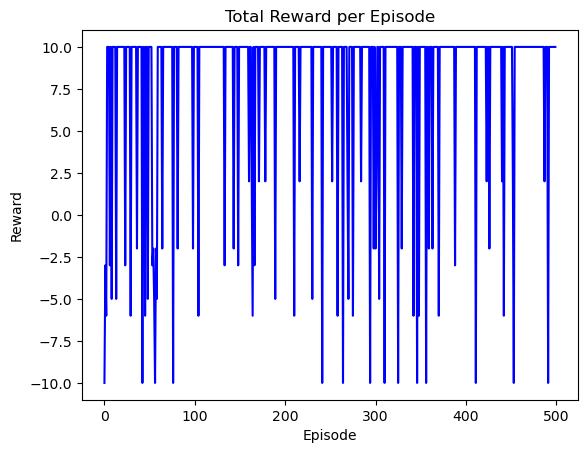

This line graph shows how the agent’s reward fluctuates across 500 episodes.
The sharp ups and downs reflect exploration during training, while the overall trend stabilizes around positive rewards. 
This indicates that the agent is learning to choose better actions over time, despite occasional negative outcomes.


In [73]:
#Part H
import matplotlib.pyplot as plt
plt.plot(rewards_per_episode, color='blue')
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()
print("""This line graph shows how the agent’s reward fluctuates across 500 episodes.
The sharp ups and downs reflect exploration during training, while the overall trend stabilizes around positive rewards. 
This indicates that the agent is learning to choose better actions over time, despite occasional negative outcomes.""")

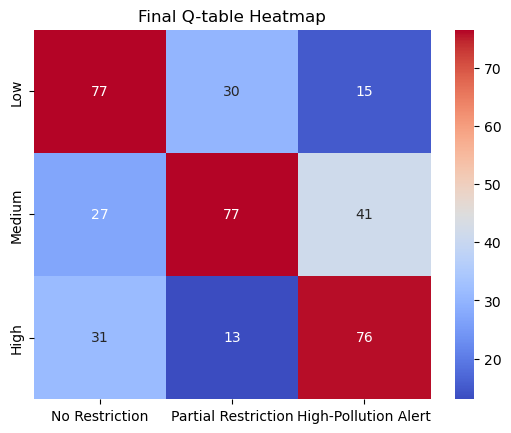

This heatmap shows the learned Q‑values for each AQI state and action. 
The highest values align with the expected best actions: No Restriction for Low AQI, Partial Restriction for Medium AQI, and High‑Pollution Alert for
High AQI. 
The colour intensity highlights how strongly each action is favored, confirming that the agent learned the correct policy.


In [79]:
import seaborn as sns
sns.heatmap(Q, annot=True, cmap="coolwarm",
            xticklabels=actions, yticklabels=states)
plt.title("Final Q-table Heatmap")
plt.show()
print("""This heatmap shows the learned Q‑values for each AQI state and action. 
The highest values align with the expected best actions: No Restriction for Low AQI, Partial Restriction for Medium AQI, and High‑Pollution Alert for
High AQI. 
The colour intensity highlights how strongly each action is favored, confirming that the agent learned the correct policy.""")

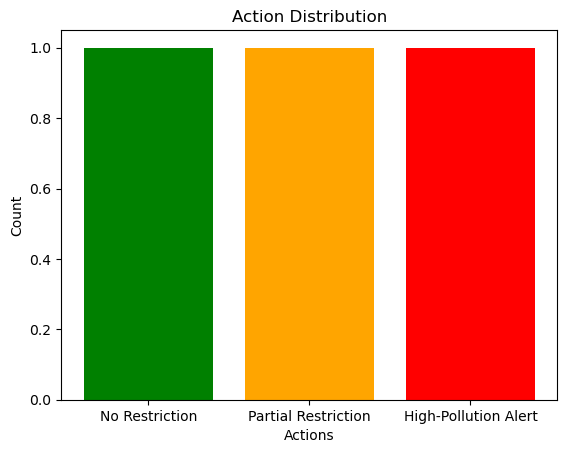

This bar chart shows how often each action was selected as the best choice. 
Each AQI state maps to one dominant action, so the counts are equal (1 each). 
This confirms that the agent consistently learned one optimal action per AQI state.


In [85]:
plt.bar(action_counts.keys(), action_counts.values(), color=['green','orange','red'])
plt.title("Action Distribution")
plt.xlabel("Actions")
plt.ylabel("Count")
plt.show()
print("""This bar chart shows how often each action was selected as the best choice. 
Each AQI state maps to one dominant action, so the counts are equal (1 each). 
This confirms that the agent consistently learned one optimal action per AQI state.""")

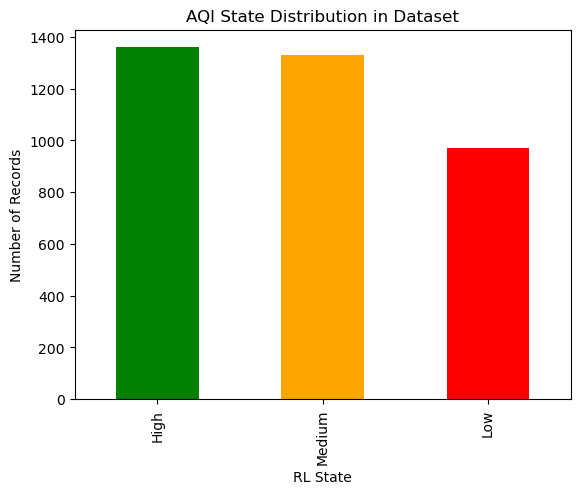

This chart connects the RL task with Assignment 3 by showing how many records fall into Low, Medium, and High AQI states. 
The dataset is skewed toward Medium and High pollution, which makes the RL agent’s training realistic and emphasizes the importance of learning correct actions for unhealthy conditions.


In [87]:
df['RL_State'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title("AQI State Distribution in Dataset")
plt.xlabel("RL State")
plt.ylabel("Number of Records")
plt.show()
print("""This chart connects the RL task with Assignment 3 by showing how many records fall into Low, Medium, and High AQI states. 
The dataset is skewed toward Medium and High pollution, which makes the RL agent’s training realistic and emphasizes the importance of learning correct actions for unhealthy conditions.""")

In [105]:
# Table 1: RL Training Parameters
training_params = pd.DataFrame({
    "Metric": [
        "Number of states used",
        "Number of actions used",
        "Episodes used for training",
        "Learning rate alpha",
        "Discount factor gamma",
        "Exploration rate epsilon",
        "Average reward after training",
        "Final learned policy"
    ],
    " Response": [
        "3 (Low, Medium, High)",
        "3",
        "500",
        "0.1",
        "0.9",
        "0.2",
        "8.06",
        "Low → No Restriction, Medium → Partial Restriction, High → High-Pollution Alert"
    ]
})
training_params


,Metric,Response
0,Number of states used,"3 (Low, Medium, High)"
1,Number of actions used,3
2,Episodes used for training,500
3,Learning rate alpha,0.1
4,Discount factor gamma,0.9
5,Exploration rate epsilon,0.2
6,Average reward after training,8.06
7,Final learned policy,"Low → No Restriction, Medium → Partial Restric..."


In [91]:
# Table 2: Learned Policy vs Explanation
policy_explanation = pd.DataFrame({
    "AQI State": ["Low AQI", "Medium AQI", "High AQI"],
    "Best Action Learned by RL Agent": ["No Restriction", "Partial Restriction", "High-Pollution Alert"],
    "Explanation": [
        "Matches expected policy. Restricting traffic during clean air is penalized, so the agent correctly avoids unnecessary restrictions.",
        "Matches expected policy. The agent balances health protection with moderate disruption, choosing partial restriction.",
        "Matches expected policy. The agent learned to issue strong alerts during hazardous conditions, protecting public health."
    ]
})

policy_explanation


,AQI State,Best Action Learned by RL Agent,Explanation
0,Low AQI,No Restriction,Matches expected policy. Restricting traffic d...
1,Medium AQI,Partial Restriction,Matches expected policy. The agent balances he...
2,High AQI,High-Pollution Alert,Matches expected policy. The agent learned to ...


In [103]:
# Part 8: RL Questions & Answers
qa = [
    ("Q1 – What is reinforcement learning?",
     "Reinforcement learning is a type of machine learning where an agent learns by interacting with an environment, "
     "receiving rewards or penalties, and improving its policy over time."),

    ("Q2 – What is the agent in this AQI traffic-control problem?",
     "The agent is the traffic-control decision maker."),

    ("Q3 – What is the environment in this problem?",
     "The environment is the AQI dataset representing pollution conditions."),

    ("Q4 – Which AQI states did you define and why?",
     "Low (0–100), Medium (101–200), High (201+). A 3-state design was chosen for simplicity and clarity."),

    ("Q5 – What are the three actions available to the agent?",
     "No Restriction, Partial Restriction, High-Pollution Alert."),

    ("Q6 – How did you design the reward system?",
     "The reward system balances public health protection and traffic disruption. Correct actions get +10, "
     "while wrong actions are penalized."),

    ("Q7 – What does exploration vs. exploitation mean?",
     "Exploration means trying random actions to discover new strategies. Exploitation means choosing the best known "
     "action based on current Q-values."),

    ("Q8 – What did the final Q-table show?",
     "The final Q-table showed high Q-values aligned with expected best actions for each AQI state."),

    ("Q9 – Which action did the agent learn for Low, Medium, and High AQI?",
     "Low → No Restriction, Medium → Partial Restriction, High → High-Pollution Alert."),

    ("Q10 – Did the RL agent make logical decisions? Explain.",
     "Yes, the learned policy matched expected logical actions, proving the agent learned correctly."),

    ("Q11 – What are the limitations of this simplified RL model?",
     "The model uses a simplified environment (random next state), tabular Q-learning only, no real traffic simulation, "
     "and is limited to 3 states and 3 actions.")
]

# Print nicely with separators
for q, a in qa:
    print("\n" + "─"*75)
    print(" ", q)
    print("─"*75)
    for line in a.split('\n'):
        print(" ", line)



───────────────────────────────────────────────────────────────────────────
  Q1 – What is reinforcement learning?
───────────────────────────────────────────────────────────────────────────
  Reinforcement learning is a type of machine learning where an agent learns by interacting with an environment, receiving rewards or penalties, and improving its policy over time.

───────────────────────────────────────────────────────────────────────────
  Q2 – What is the agent in this AQI traffic-control problem?
───────────────────────────────────────────────────────────────────────────
  The agent is the traffic-control decision maker.

───────────────────────────────────────────────────────────────────────────
  Q3 – What is the environment in this problem?
───────────────────────────────────────────────────────────────────────────
  The environment is the AQI dataset representing pollution conditions.

───────────────────────────────────────────────────────────────────────────
  Q4 – Whic